In [ ]:
import os
#os.environ["KAGGLE_API_TOKEN"]="xxxxxx"
#KAGGLE_API_TOKEN=xxxxxxx
#! bash export KAGGLE_API_TOKEN=xxxxxx

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
!cd C:\Users\Cyril\Documents\python\jedha\M11_projet\explo\music_genre_classification

In [2]:
!echo $env:KAGGLE_API_TOKEN

$env:KAGGLE_API_TOKEN


In [ ]:
!cd ..

In [3]:
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other

Connection error: ChunkedEncodingError: ('Connection broken: IncompleteRead(1147746896 bytes read, 153745599 more expected)', IncompleteRead(1147746896 bytes read, 153745599 more expected))
Retrying in 2.1 seconds... (attempt 1/5)
Retry 1/5: Resuming from 1147142144 bytes (154350351 bytes left)...




  0%|          | 0.00/1.21G [00:00<?, ?B/s]
  0%|          | 1.00M/1.21G [00:01<21:28, 1.01MB/s]
  0%|          | 2.00M/1.21G [00:02<23:10, 935kB/s] 
  0%|          | 3.00M/1.21G [00:02<19:15, 1.12MB/s]
  0%|          | 4.00M/1.21G [00:03<17:16, 1.25MB/s]
  0%|          | 5.00M/1.21G [00:04<15:56, 1.36MB/s]
  0%|          | 6.00M/1.21G [00:05<16:56, 1.27MB/s]
  1%|          | 7.00M/1.21G [00:15<1:19:19, 272kB/s]
  1%|          | 8.00M/1.21G [00:17<1:09:18, 311kB/s]
  1%|          | 9.00M/1.21G [00:19<57:57, 372kB/s]  
  1%|          | 10.0M/1.21G [00:20<46:09, 466kB/s]
  1%|          | 11.0M/1.21G [00:22<48:05, 447kB/s]
  1%|          | 12.0M/1.21G [00:23<38:25, 559kB/s]
  1%|          | 13.0M/1.21G [00:24<29:42, 722kB/s]
  1%|          | 14.0M/1.21G [00:25<27:51, 770kB/s]
  1%|          | 15.0M/1.21G [00:27<32:43, 655kB/s]
  1%|▏         | 16.0M/1.21G [00:29<34:45, 616kB/s]
  1%|▏         | 17.0M/1.21G [00:30<28:58, 738kB/s]
  1%|▏         | 18.0M/1.21G [00:30<22:33, 948kB/s]
  2%|▏ 

In [3]:
import kagglehub
import kagglesdk

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

ImportError: cannot import name 'get_web_endpoint' from 'kagglesdk.kaggle_env' (c:\work\Venv\venv_311_jedha\Lib\site-packages\kagglesdk\kaggle_env.py)

In [15]:
# Usual Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn

# Librosa (the mother of audio files)
import librosa
import librosa.display
import IPython.display as ipd
import warnings
warnings.filterwarnings('ignore')

In [10]:
import os
os.getcwd()

'c:\\Users\\Cyril\\Documents\\python\\jedha\\M11_projet\\explo\\music_genre_classification'

In [ ]:
import os
# Cyril data located 2 steps above :
general_path = '../../gtzan-dataset-music-genre-classification/Data'
print(list(os.listdir(f'{general_path}/genres_original/')))

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## Explore Audio Data¶

We will use librosa, which is the mother of audio files.
Understanding Audio

Let's first Explore our Audio Data to see how it looks (we'll work with reggae.00036.wav file).

    Sound: sequence of vibrations in varying pressure strengths (y)
    The sample rate (sr) is the number of samples of audio carried per second, measured in Hz or kHz


In [30]:
# Importing 1 file
genre = "reggae"
audio_file_name = "reggae.00039"
y, sr = librosa.load(f"{general_path}/genres_original/{genre}/{audio_file_name}.wav")

print('y:', y, '\n')
print('y shape:', np.shape(y)[0], '\n')
print('Sample Rate (KHz):', sr, '\n')

# Verify length of the audio
print(f"Check Len of Audio: {np.shape(y)[0]/sr:2.2f} s")

y: [-0.02325439 -0.03765869 -0.03546143 ...  0.03512573  0.03808594
  0.03692627] 

y shape: 661794 

Sample Rate (KHz): 22050 

Check Len of Audio: 30.01 s


In [31]:
# Trim leading and trailing silence from an audio signal (silence before and after the actual audio)
audio_file, _ = librosa.effects.trim(y)

# the result is an numpy ndarray
print('Audio File:', audio_file, '\n')
print('Audio File shape:', np.shape(audio_file))

Audio File: [-0.02325439 -0.03765869 -0.03546143 ...  0.03512573  0.03808594
  0.03692627] 

Audio File shape: (661794,)


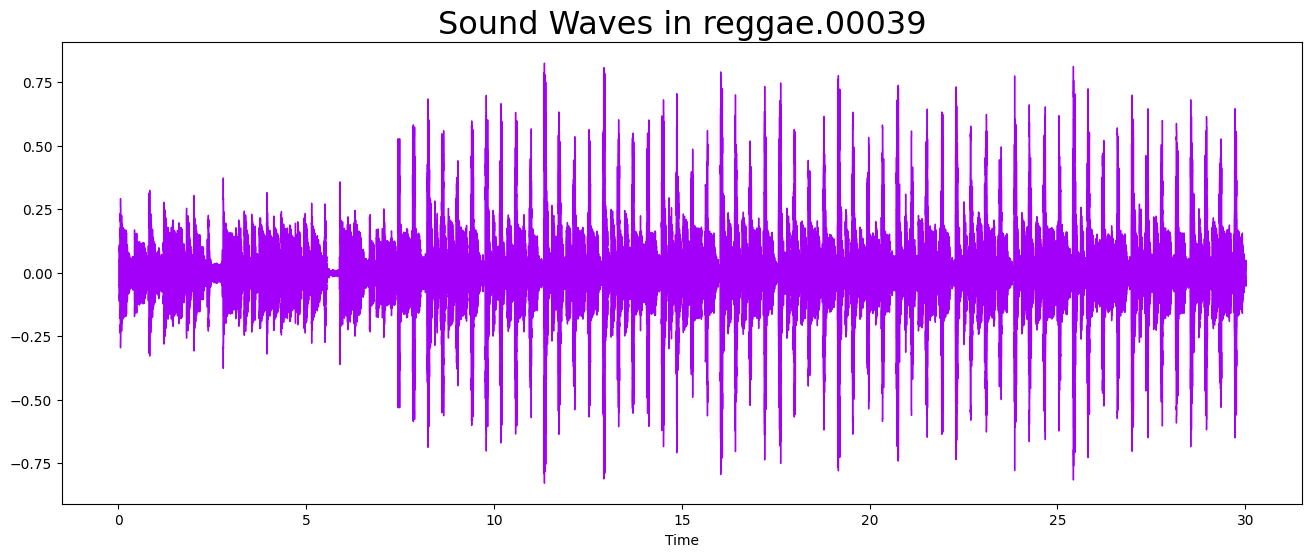

In [32]:
plt.figure(figsize = (16, 6))
librosa.display.waveshow(y = audio_file, sr = sr, color = "#A300F9");
plt.title(f"Sound Waves in {audio_file_name}", fontsize = 23);

# Fourier Transform¶

    Function that gets a signal in the time domain as input, and outputs its decomposition into frequencies
    Transform both the y-axis (frequency) to log scale, and the “color” axis (amplitude) to Decibels, which is approx. the log scale of amplitudes.


In [33]:
# Default FFT window size
n_fft = 2048 # FFT window size
hop_length = 512 # number audio of frames between STFT columns (looks like a good default)

# Short-time Fourier transform (STFT)
D = np.abs(librosa.stft(audio_file, n_fft = n_fft, hop_length = hop_length))

print('Shape of D object:', np.shape(D))

Shape of D object: (1025, 1293)


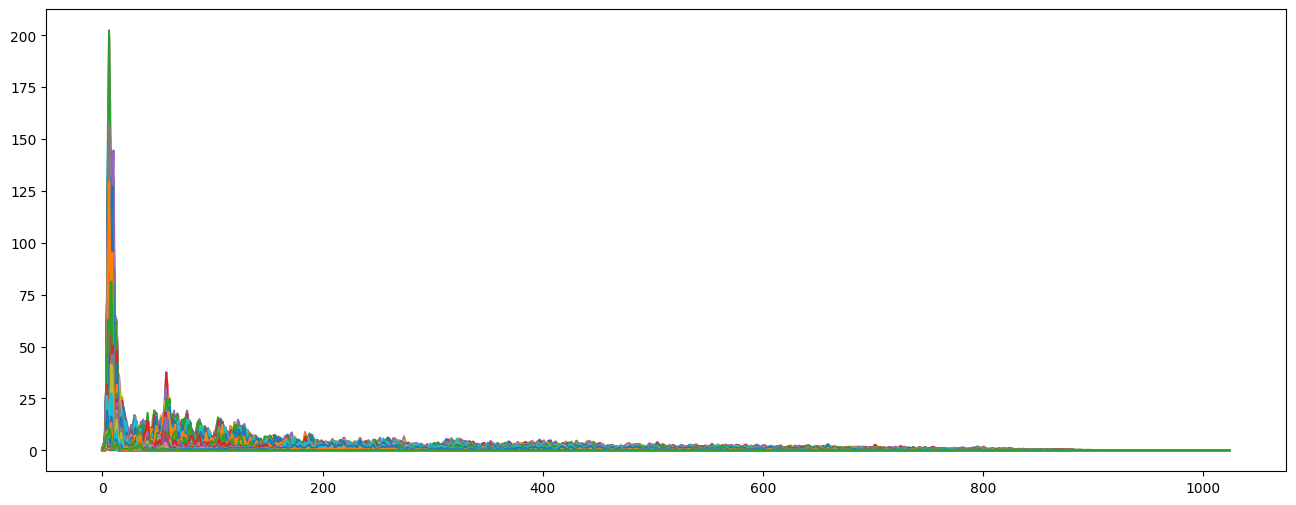

In [34]:
plt.figure(figsize = (16, 6))
plt.plot(D);

# The Spectrogram¶

    What is a spectrogram? A spectrogram is a visual representation of the spectrum of frequencies of a signal as it varies with time. When applied to an audio signal, spectrograms are sometimes called sonographs, voiceprints, or voicegrams (wiki).
    Here we convert the frequency axis to a logarithmic one.


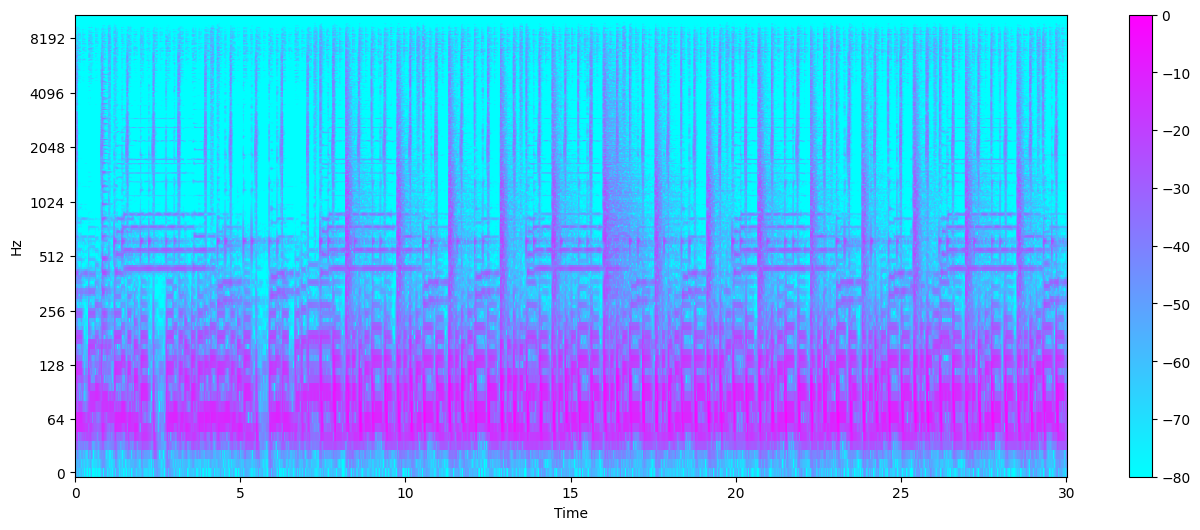

In [35]:
# Convert an amplitude spectrogram to Decibels-scaled spectrogram.
DB = librosa.amplitude_to_db(D, ref = np.max)

# Creating the Spectogram
plt.figure(figsize = (16, 6))
librosa.display.specshow(DB, sr = sr, hop_length = hop_length, x_axis = 'time', y_axis = 'log',
                        cmap = 'cool')
plt.colorbar();